# Colorectal Cancer Histology Classification using PathMNIST

This notebook will cover data preparation, model fine-tuning, evaluation, and interpretability using the PathMNIST dataset.

This dataset comes in [MedMNIST](https://github.com/MedMNIST/MedMNIST/), a large-scale MNIST-like collection of standardised biomedical images, including 12 datasets for 2D and 6 datasets for 3D. All images are standardised into multiple size options with the corresponding classification labels, so that no background knowledge is required for users.


PathMNIST is based on a study for predicting survival from colorectal cancer histology slides, and we will use non-overlapping 28x28 image patches extracted from Hematoxylin and Eosin (H&E) stained histological images.

You will develop a multi-class classification task, with the following classes:


* Adipose
* Background
* Debris
* Lymphocytes
* Mucus
* Smooth muscle
* Normal colon mucosa
* Cancer-associated stroma
* Colorectal adenocarcinoma epithelium





Let's start by installing and importing the right packages

In [ ]:
# Setup Environment
!pip install medmnist grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=7bf88b568c54be21fb0ebcf8b59511585efaa506c8df161aedcd5cfe5bb75dc0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import medmnist
from medmnist import INFO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Exercise 1: Data Loading & Preprocessing

**Task:** Load the PathMNIST dataset and prepare PyTorch DataLoaders.

**Pointers:**
* Use `medmnist.INFO['pathmnist']` to retrieve dataset metadata and the corresponding Python class.
* MedMNIST images are 28x28. Pre-trained models like ResNet expect 224x224, so you should apply a resize transformation.
* Convert to tensor and normalize using standard ImageNet mean `[0.485, 0.456, 0.406]` and standard deviation `[0.229, 0.224, 0.225]`.
* Instantiate training, validation, and testing datasets and their respective DataLoaders.

**Suggestion:**
* Start with only 10% of the training and validation sets for training to be faster.

In [ ]:
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Define transforms
data_transform = transforms.Compose([
    # Resize, ToTensor, Normalize
])

# Load datasets
# train_dataset = DataClass(split=...
# val_dataset = ...
# test_dataset = ...

# Subsample 10% of the data to accelerate training
# train_dataset, _ = random_split(train_dataset, [0.1, 0.9])
# val_dataset, _ = random_split(val_dataset, [0.1, 0.9])

# Create DataLoaders
# train_loader = ...
# val_loader = ...
# test_loader = ...

In [ ]:
# Solution
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

data_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

train_dataset, _ = random_split(train_dataset, [0.1, 0.9])
val_dataset, _ = random_split(val_dataset, [0.1, 0.9])

train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 9000, Val samples: 1001, Test samples: 7180


# Exercise 2: Model fine-tuning

**Task:** Initialise a pre-trained ResNet18 model, and fine-tune it on PathMNIST

**Pointers:**
* Use `torchvision.models.resnet18(pretrained=True)`.
* Replace the final fully connected layer to match the 9 classes of PathMNIST.

**Suggestions:**
* Start with optim.Adam with a learning rate of 1e-3.
* Train only for 3 epochs on a first try such that you can more quickly do all the notebook's exercises in today's session.
* Don't forget to apply a validation step per epoch to keep track of potential overfitting.


In [ ]:
# Initialize model
# model = ...

# Loss and Optimizer
# criterion = ...
# optimizer = ...

# Training Loop
num_epochs = 3
# for epoch in range(num_epochs):
#     # Implement training and validation steps

In [ ]:
# EXERCISE 2: SOLUTION
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(info['label']))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.squeeze().long().to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == targets.data)

    val_acc = val_correct.double() / len(val_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1/3 - Train Loss: 0.4309 - Val Acc: 0.6414
Epoch 2/3 - Train Loss: 0.2513 - Val Acc: 0.6513
Epoch 3/3 - Train Loss: 0.1602 - Val Acc: 0.8881


# Exercise 3: Performance evaluation

**Task:** Evaluate the trained model on the test set

**Pointers:**
* Include at least the Macro F1 score, such that we can use that metric for comparison with other people and see who is able to get the highest performance.
* Beyond the usual metrics, also plot a confusion matrix.




In [ ]:
# Collect predictions and true labels
y_true = []
y_pred = []

# model.eval()
# with torch.no_grad():
#     # Iterate over test_loader and populate y_true, y_pred

# Compute metrics
# acc = ...
# f1 = ...
# cm = ...

Test Accuracy: 0.7925
Test Macro F1: 0.7270


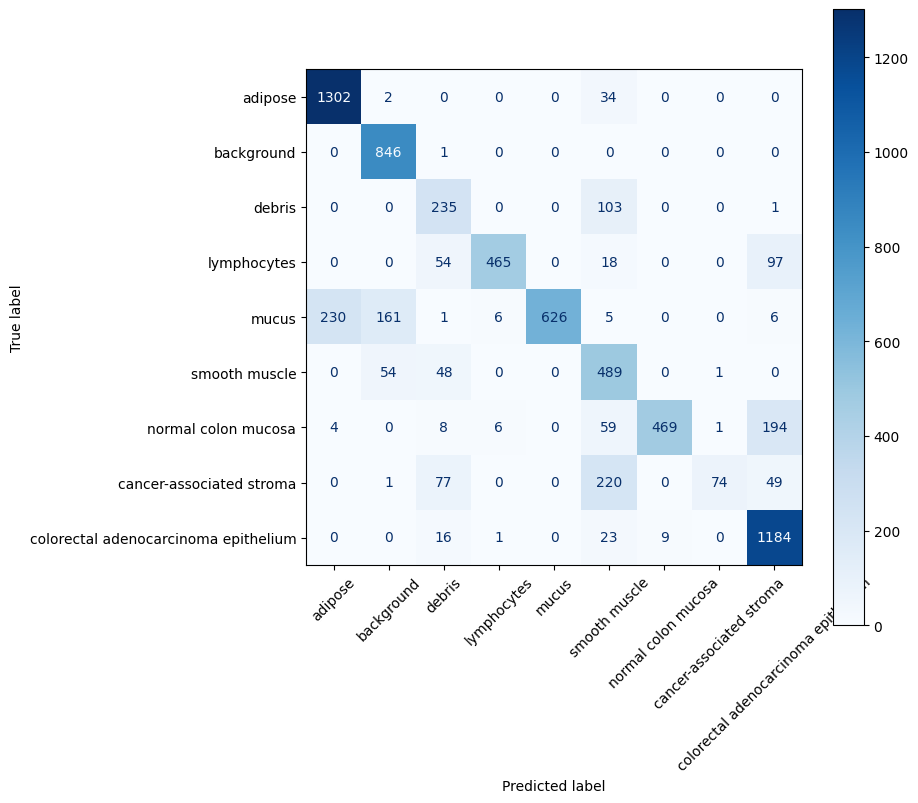

In [ ]:
# EXERCISE 3: SOLUTION
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.squeeze().long()
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(info['label'].values()))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.show()

# Exercise 4: Visualisation and Interpretability

**Task:** Apply Grad-CAM to patches from the test set to visually check predictions and try to interpret model's predictions by visualising attention heatmaps.

**Pointers:**
* Target the last convolutional layer of ResNet18: `target_layers = [model.layer4[-1]]`.
* Don't forget to "un-normalize" the tensor image for visualization: `img_viz = img_tensor.permute(1, 2, 0).numpy() * std + mean`.
* Include the ground truth and predicted labels information such that you can see if you are seeing a heatmap of a correct or wrong prediction.


**Suggestion:**
* Use `pytorch_grad_cam`'s `show_cam_on_image(img_viz, grayscale_cam, use_rgb=True)` (already imported) to make it easier to overlay the heatmap on the input image.


In [ ]:
# Select 5 samples as a starting point
# subset_indices = range(5)
# subset = torch.utils.data.Subset(test_dataset, subset_indices)

# target_layers = [model.layer4[-1]]
# cam = GradCAM(model=model, target_layers=target_layers)

# for img, label in subset:
#     # Prepare input tensor, generate CAM, unnormalize image, plot
#     pass

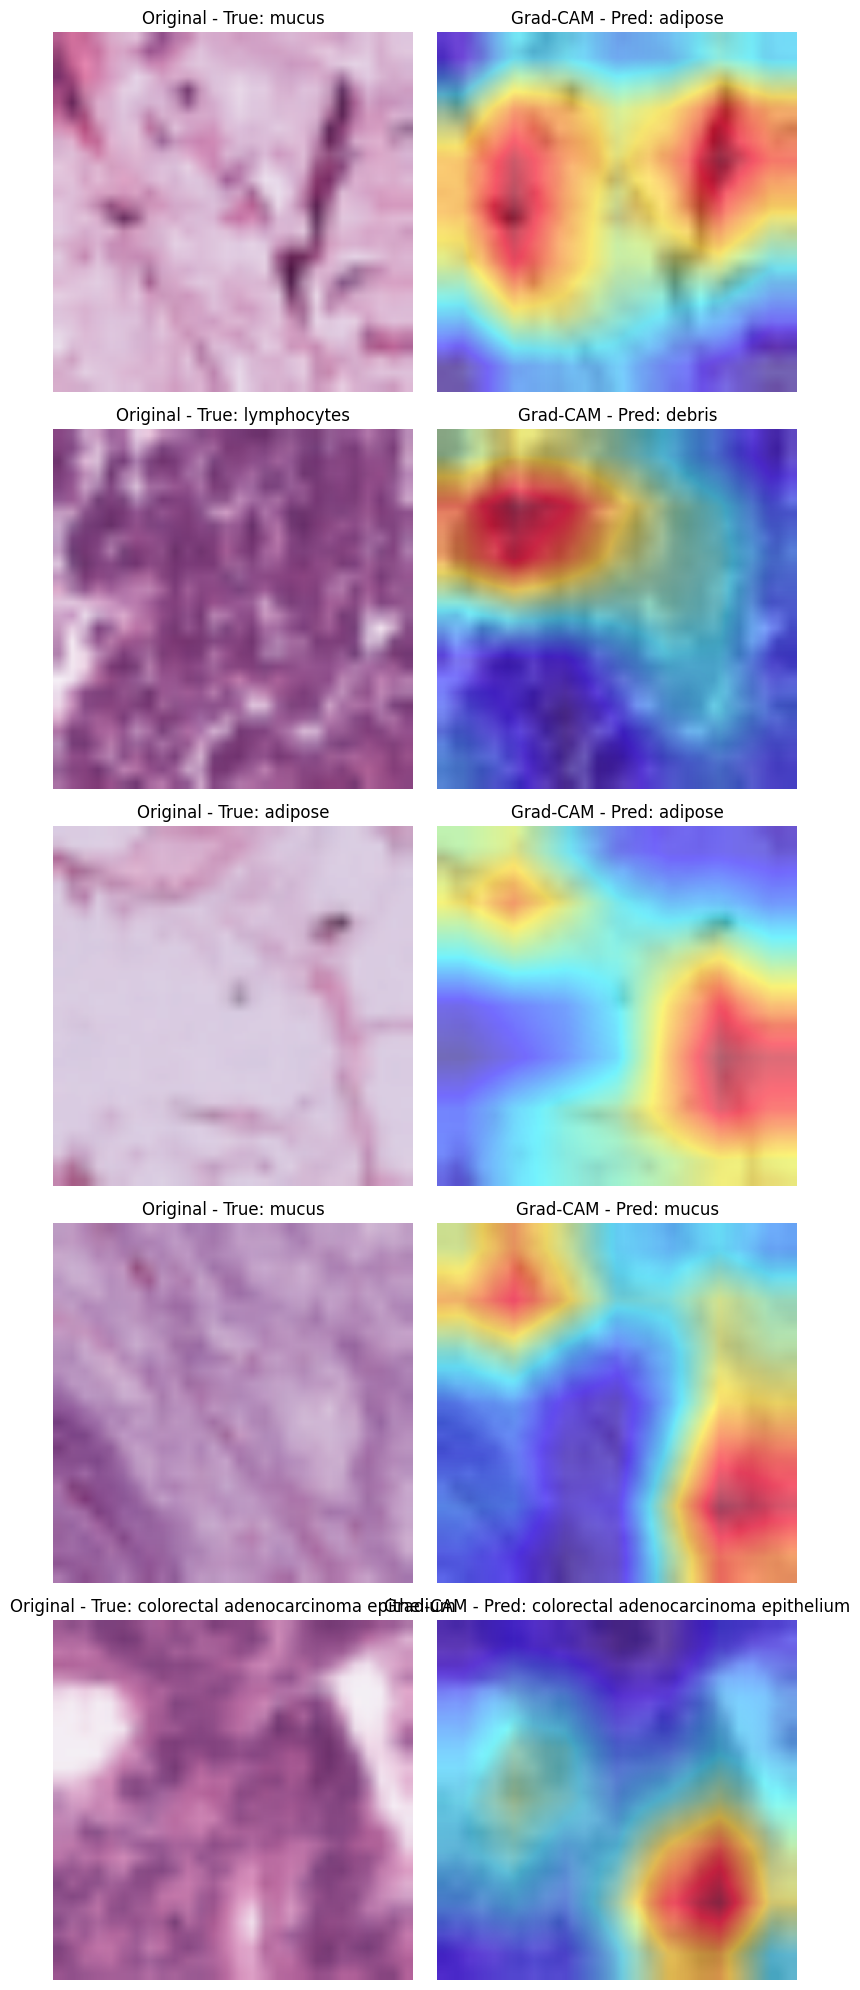

In [ ]:
# EXERCISE 4: SOLUTION
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

class_names = list(info['label'].values())
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(5, 2, figsize=(8, 20))

for i in range(5):
    img_tensor, label = test_dataset[i]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Get model prediction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output).item()

    # Generate CAM
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Denormalize image for display
    img_viz = img_tensor.permute(1, 2, 0).numpy()
    img_viz = std * img_viz + mean
    img_viz = np.clip(img_viz, 0, 1)

    # Overlay CAM
    cam_image = show_cam_on_image(img_viz, grayscale_cam, use_rgb=True)

    # Plotting
    axes[i, 0].imshow(img_viz)
    axes[i, 0].set_title(f"Original - True: {class_names[label.item()]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title(f"Grad-CAM - Pred: {class_names[pred_idx]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Exercise 5: Improving performance

**Task:** Now that you have all the code needed to train and run inference on PathMNIST, try to improve the performance you get on the test set.


**Suggestions:**

*(Notice that some of them will likely have a different time/impact balance)*
* Increase the proportion of the training/validation data used and extend the number of epochs used for training.
* Replace ResNet18 with other architectures (eg `efficientnet_b0` or `vit_b_16`)  and analyse how this choice impacts convergence speed and Grad-CAM spatial localisation.
* Change the transfer learning strategy to freeze all feature layers (`param.requires_grad = False`) but the final one, such that you fine-tune only the final classification head.
* Introduce stain augmentation techniques during training.